<a href="https://colab.research.google.com/github/Fedorov-Kirill/-Pavlova/blob/main/%D0%9A%D0%BE%D0%BF%D0%B8%D1%8F_%D0%B1%D0%BB%D0%BE%D0%BA%D0%BD%D0%BE%D1%82%D0%B0_%22%D0%9A%D0%BE%D0%BF%D0%B8%D1%8F_%D0%B1%D0%BB%D0%BE%D0%BA%D0%BD%D0%BE%D1%82%D0%B0_%22_%D0%9B%D0%B8%D0%BD%D0%B5%D0%B9%D0%BD%D0%B0%D1%8F_%D1%80%D0%B5%D0%B3%D1%80%D0%B5%D1%81%D1%81%D0%B8%D1%8F%2C_%D0%B3%D1%80%D0%B0%D0%B4%D0%B8%D0%B5%D0%BD%D1%82%D0%BD%D1%8B%D0%B9_%D1%81%D0%BF%D1%83%D1%81%D0%BA_ipynb%22%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **План**

- Реализация алгоритма стохастического градиентного спуска:
    - загрузка данных
    - создание и обучение алгоритма
- Сравнение написанного алгоритма с реализованным в библиотеке Sklearn.

- Рекомендованная литература

ноутбук в колаб: https://drive.google.com/file/d/1aqRvKK0WRq8hn89bm1O__khM5cg1wuW7/view?usp=sharing

# Реализуем алгоритм стохастического градиентного спуска

In [ ]:
import numpy as np

import pandas as pd
import matplotlib.pyplot as plt

## Загрузка и подготовка данных

### **Постановка задачи:**
Предсказать вероятность одобрения заявки на поступление в ВУЗ (вероятность от 0 до 1) по набору признаков: оценки за экзамены, наличие research и тд

In [ ]:
df = pd.read_csv('https://raw.githubusercontent.com/tixonsit/mmdad_materials/master/datasets_14872_228180_Admission_Predict_Ver1.1.csv')
del df['Serial No.']

In [ ]:
df.head()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,337,118,4,4.5,4.5,9.65,1,0.92
1,324,107,4,4.0,4.5,8.87,1,0.76
2,316,104,3,3.0,3.5,8.00,1,0.72
3,322,110,3,3.5,2.5,8.67,1,0.80
4,314,103,2,2.0,3.0,8.21,0,0.65


In [ ]:
# мало :(
len(df)

500

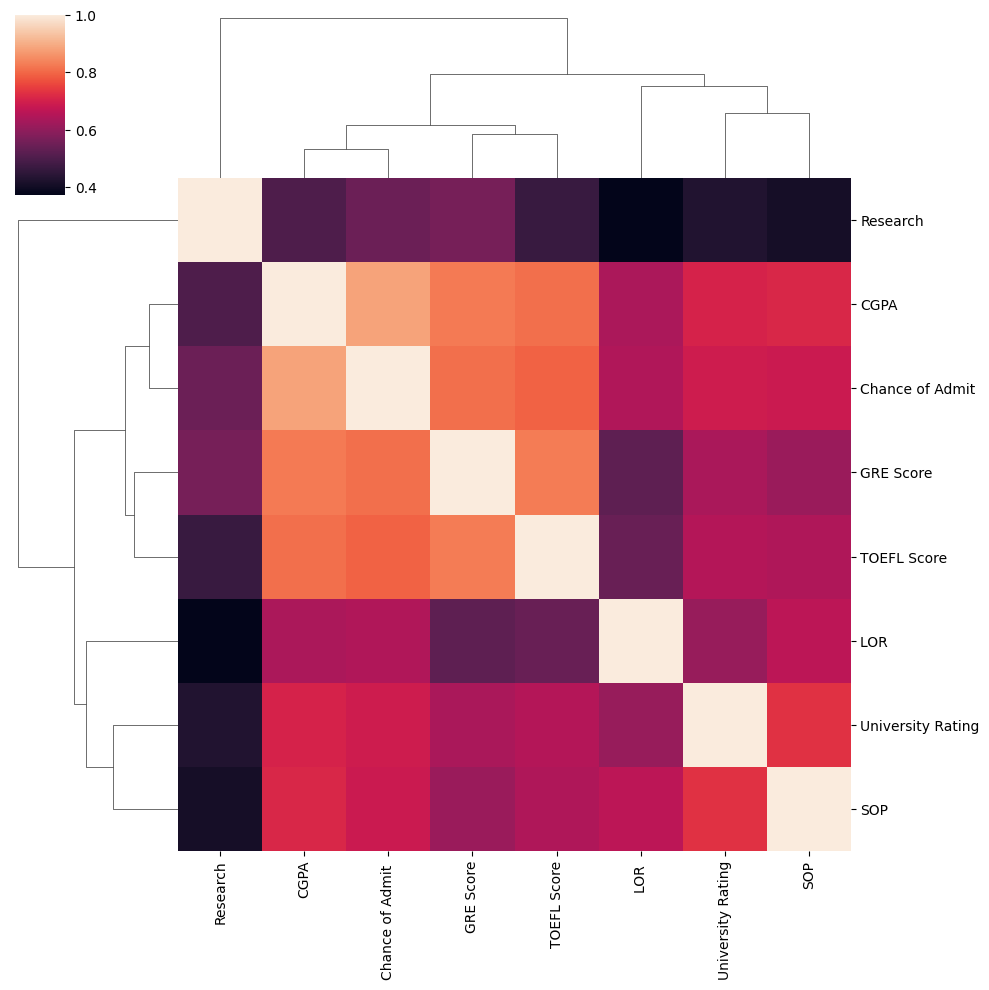

In [ ]:
import seaborn as sns

sns.clustermap(df.corr())

In [ ]:
# перемешка
df = df.sample(frac=1).reset_index(drop=True)
# train test split
df_train = df[:400]
df_test = df[400:]
# среднее и стандартное отклонение
mean = df.mean(axis=0)
std = df.std(axis=0)
# 0 мат ожидание и 1 дисперсию
df_train = (df_train - mean)/std

X_train = df_train.drop(columns=['Chance of Admit ']).values
y_train = df_train['Chance of Admit '].values
df_test = (df_test - mean)/std
X_test = df_test.drop(columns=['Chance of Admit ']).values
y_test = df_test['Chance of Admit '].values

In [ ]:
X_train[:5]

array([[-1.19272448, -1.34695466, -0.09969289, -1.38647324, -1.06326701,
        -1.51524571, -1.12702343],
       [-0.04178785,  0.2972771 ,  0.77480617,  1.13622188,  0.01728889,
         0.30349887,  0.88551841],
       [ 0.48941367,  0.46170028,  1.64930524,  1.13622188,  0.55756685,
         0.65071374, -1.12702343],
       [ 0.84354802,  1.11939299, -0.09969289, -0.37739519, -0.52298906,
         0.88219032,  0.88551841],
       [ 1.55181671,  1.44823934,  0.77480617,  0.63168286, -0.52298906,
        -0.95308829,  0.88551841]])

In [ ]:
y_train[:5]

array([-2.56297977,  0.12937472,  0.41278045,  0.76703762,  0.41278045])

## Создание алгоритма

In [ ]:
print('размерность пространства признаков:', X_train.shape[1])
# инициализация весов под размерность пространства признаков
w = np.ones(X_train.shape[1])
# выбираем случайный индекс, по которому найдем частную производную
ind = np.random.randint(X_train.shape[1])
print('Случайный индекс', ind)
# переможим выбранный столбец на нужный вес (получаем кол-во элементов train)
len(np.dot(X_train[:,ind], w[ind]))

размерность пространства признаков: 7
Случайный индекс 6


400

$$MSE = \frac{1}{n}\sum_{i = 1}^{n}(y_i - \hat{y_i})^2$$

Реализуем ошибку по формуле:

In [ ]:
mse = lambda y, y_pred:((y-y_pred)**2).sum()/len(y_pred)

In [ ]:
# очистка экрана
from google.colab import output
# коэффициент детерминации
from sklearn.metrics import r2_score

Стохастический градиентный спуск (англ. stochastic gradient descent, SGD) − оптимизационный алгоритм, отличающийся от обычного градиентного спуска тем, что градиент оптимизируемой функции считается на каждом шаге не как сумма градиентов от каждого элемента выборки, а как градиент от одного, случайно выбранного элемента.

![dssmall](https://github.com/m9psy/neural_network_habr_guide/blob/master/Part%203/images/stochastic.gif?raw=true)

$$w_{t+1} = w_{t} - \frac{2\alpha}{n}X_i(<X_i, w_{t}> - y_i) $$

Реализуем шаг по формуле

In [ ]:
gradient_step_stah = lambda X, y, w, alpha, ind: w - (alpha* 2.0 / X.shape[0]) * X[ind] * (np.dot(X[ind], w) - y[ind])

In [ ]:
# выбрали случайный индекс
ind = np.random.randint(X_train.shape[1])
# сделали один шаг (w = [1, 1, ...])
gradient_step_stah(X_train, y_train, np.ones(X_train.shape[1]), 1e-4, ind)

array([1.00000007, 0.99999952, 0.99999874, 0.99999816, 0.99999997,
       0.99999951, 0.99999856])

In [ ]:
X_train.shape[1]

7

## Обучение алгоритма

In [ ]:
# стохастический градиентный спуск
def sgd(X, y, w, alpha = 1e-4, max_it = 10e6):
    # номер итерации
    iter_num = 0
    # ошибки на трейне
    errors = []
    # ошибки на тесте
    errors_test = []
    # r2 на тесте
    r2 = []
    while (iter_num < max_it):
        # выбираем случайный элемент
        ind = np.random.randint(X.shape[0])
        # обновляем веса град спуском
        w = gradient_step_stah(X, y, w, alpha, ind)
        # отображаем каждый %
        if iter_num%(int(max_it/100))==0:
            # очищаем экран

            print('Выполнено:', int(iter_num/max_it * 100), '%')
            # mse train
            error = mse(y_train,np.dot(X_train, w))
            errors.append(error)
            print('Mse train:', error)
            # mse test
            error = mse(y_test,np.dot(X_test, w))
            errors_test.append(error)
            print('Mse test:', error)
            # r2 test
            R = r2_score(y_test,np.dot(X_test, w))
            r2.append(R)
            print('R2:', R)
        iter_num += 1

    return w, errors, errors_test, r2

w, mse_train, mse_test, r2 = sgd(X_train, y_train, np.ones(X_train.shape[1]))

Выполнено: 0 %
Mse train: 23.539955438260737
Mse test: 23.775208457056568
R2: -24.936594583104686
Выполнено: 1 %
Mse train: 14.794571518111047
Mse test: 14.984251259017544
R2: -15.34645814939907
Выполнено: 2 %
Mse train: 9.324373165589545
Mse test: 9.47313365261011
R2: -9.334329031146273
Выполнено: 3 %
Mse train: 5.8960012684979795
Mse test: 6.009153474416499
R2: -5.555441048397485
Выполнено: 4 %
Mse train: 3.7846334717155834
Mse test: 3.8682210194715467
R2: -3.2198780515886307
Выполнено: 5 %
Mse train: 2.456320169642994
Mse test: 2.515191509809007
R2: -1.7438456578251809
Выполнено: 6 %
Mse train: 1.6336697345099194
Mse test: 1.67261776200616
R2: -0.8246741711649519
Выполнено: 7 %
Mse train: 1.117362313903438
Mse test: 1.1401654864635822
R2: -0.24381706404248926
Выполнено: 8 %
Mse train: 0.7948449167591584
Mse test: 0.8048203978759088
R2: 0.12201399160709003
Выполнено: 9 %
Mse train: 0.5916113121018053
Mse test: 0.5913697891493355
R2: 0.3548692329000377
Выполнено: 10 %
Mse train: 0.463

In [ ]:
from matplotlib.pyplot import figure

plt.figure(figsize=(15,10))
plt.grid()

plt.plot(mse_train, label = 'train')
plt.plot(mse_test, label = 'test')
plt.legend()

In [ ]:
from matplotlib.pyplot import figure

plt.figure(figsize=(15,10))
plt.grid()

plt.plot(r2, label = 'r2')
plt.legend()

In [ ]:
print('веса', w)
print('R^2 = ', r2_score(y_test, np.dot(X_test,w)))

In [ ]:
# массив результатов
r2_shuffles = []
# проверим, зависит ли изначальная перемешка от результата
for i in range(2):
    print(f'Итерация {i+1}')
    # перемешка
    df = df.sample(frac=1).reset_index(drop=True)
    # train test split
    df_train = df[:400]
    df_test = df[400:]
    # среднее и стандартное отклонение
    mean = df.mean(axis=0)
    std = df.std(axis=0)
    # 0 мат ожидание и 1 дисперсию
    df_train = (df_train - mean)/std
    X_train = df_train.drop(columns=['Chance of Admit ']).values
    y_train = df_train['Chance of Admit '].values
    df_test = (df_test - mean)/std
    X_test = df_test.drop(columns=['Chance of Admit ']).values
    y_test = df_test['Chance of Admit '].values

    w, mse_train, mse_test, r2 = sgd(X_train, y_train, np.ones(X_train.shape[1]))
    print(f'Итерация {i+1} | R^2 = ', r2_score(y_test, np.dot(X_test,w)))
    r2_shuffles.append(r2_score(y_test, np.dot(X_test,w)))

In [ ]:
fig1, ax1 = plt.subplots()
ax1.set_title('R^2 в результате перемешки')
ax1.boxplot(r2_shuffles)

Вывод: сильно зависит от перемешки -> данные нерепрезентативны -> накапливаем еще или аугментируем

# Сравнение с Sklearn

## Обучение с помощью sklearn

In [ ]:
from sklearn.linear_model import SGDRegressor
# инициализируем и обучаем
reg = SGDRegressor()
reg.fit(X_train, y_train)

In [ ]:
print('Mse sgd (sklearn): ', r2_score(y_test, reg.predict(X_test)))

Настраиваем тонко

In [ ]:
from sklearn.model_selection import GridSearchCV

grid = {'penalty': ['l1', 'l2'],
        'alpha': [1e-4, 1e-5, 1e-6, 1e-7]}

reg = SGDRegressor()
gs = GridSearchCV(reg, grid, cv=5)

# Обучаем его
gs.fit(X_train, y_train)
gs.best_params_, gs.best_score_

In [ ]:
from sklearn.linear_model import SGDRegressor
# инициализируем и обучаем
reg = SGDRegressor(alpha = 1e-05, penalty = 'l2')
reg.fit(X_train, y_train)

In [ ]:
print('Mse sgd (sklearn): ', r2_score(y_test, reg.predict(X_test)))

In [ ]:
fin_score = []

for i in range(30):
    print(f'Итерация {i+1}')
    # перемешка
    df = df.sample(frac=1).reset_index(drop=True)
    # train test split
    df_train = df[:400]
    df_test = df[400:]
    # среднее и стандартное отклонение
    mean = df.mean(axis=0)
    std = df.std(axis=0)
    # 0 мат ожидание и 1 дисперсию
    df_train = (df_train - mean)/std
    X_train = df_train.drop(columns=['Chance of Admit ']).values
    y_train = df_train['Chance of Admit '].values
    df_test = (df_test - mean)/std
    X_test = df_test.drop(columns=['Chance of Admit ']).values
    y_test = df_test['Chance of Admit '].values

    # обучение
    grid = {'penalty': ['l1', 'l2'],
            'alpha': [1e-4, 1e-5, 1e-6, 1e-7]}

    reg = SGDRegressor()
    gs = GridSearchCV(reg, grid, cv=5, scoring = 'r2')

    # Обучаем его
    gs.fit(X_train, y_train)
    print(gs.best_score_)
    fin_score.append(gs.best_score_)

In [ ]:
fig1, ax1 = plt.subplots()
ax1.set_title('R^2 в результате перемешки (+ регуляризация)')
ax1.boxplot(fin_score)

# Вывод

- Реализован стохастический градиентный спуск (СГС) для задачи линейной регрессии

- Приведено сравнение написанного СГС и реализованного в библиотеке sklearn


# Рекомендованная литература


- [Линейная регрессия в подробностях](https://habr.com/ru/company/ods/blog/322076/)


- [Функция ошибок в задачах регрессии](https://alexanderdyakonov.files.wordpress.com/2018/10/book_08_metrics_12_blog1.pdf)

- Градиентный спуск:
    - [Часть 1](https://habr.com/ru/post/307312/)
    - [Часть 2](https://habr.com/ru/post/308604/)
